# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [2]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [3]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [5]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\output.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\frames_real")

FPS : 30.0
Nombre total de trames : 101
101 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel
FPS : 30.0
Nombre total de trames : 798
798 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\frames_real


In [6]:
dossier_fake = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\frames")
dossier_real = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")

In [7]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouvés dans {dossier_fake}")

121 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\frames


In [8]:

real_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_real.rglob("*")
    if f.is_file()
)

print(f"{len(real_frame_paths)} fichiers trouvés dans {dossier_real}")


print()


101 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel



In [9]:

KEYFRAME_PATH = real_frame_paths[0]
TARGET_PATH= real_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00001.png


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [10]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(480, 640)


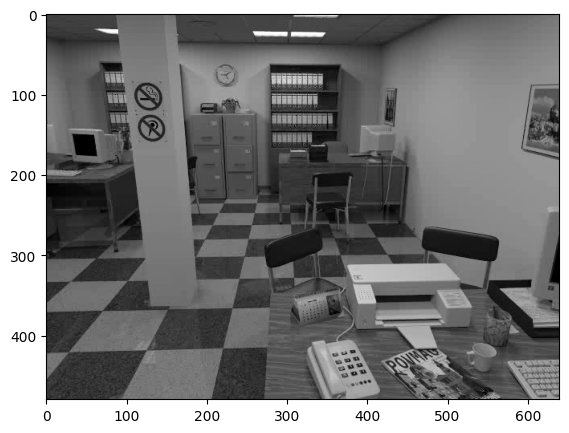

In [11]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [12]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [13]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
keyframe_image shape = (480, 640) dtype = uint8
keyframe_depth shape = (480, 640) dtype = float32
depth min/max = 1.8346056938171387 84.0458755493164
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

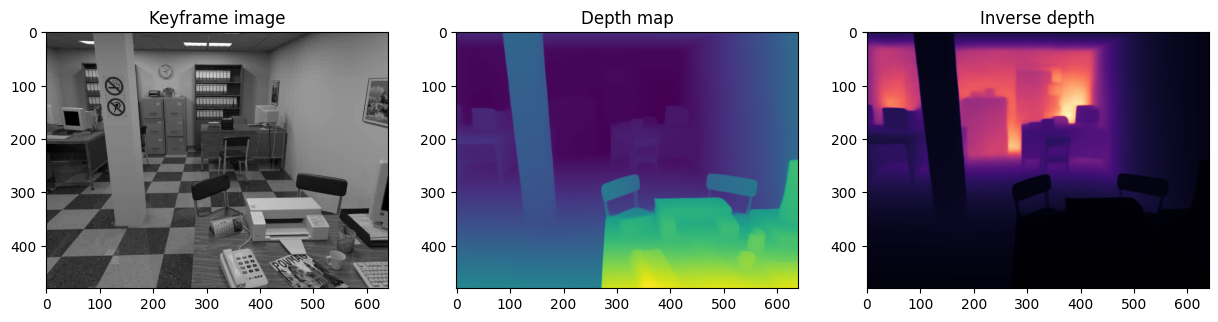

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.


In [15]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height
USER_FX = 481.20
USER_FY = 480.0
USER_CX = 319.5
USER_CY = 239.5

intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 640
  height = 480

USER intrinsics chosen at the beginning of the notebook:
{'width': 640, 'height': 480, 'fx': 481.2, 'fy': 480.0, 'cx': 319.5, 'cy': 239.5}

K_user =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]


In [16]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 1.0
  scale_y = 1.0

  USER_FX -> cam.fx[0] : 481.2 -> 481.2
  USER_FY -> cam.fy[0] : 480.0 -> 480.0
  USER_CX -> cam.cx[0] : 319.5 -> 319.5
  USER_CY -> cam.cy[0] : 239.5 -> 239.5

Expected level-0 values after internal resize:
  expected fx = 481.2
  expected fy = 480.0
  expected cx = 319.5
  expected cy = 239.5

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [17]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 481.200000, 480.000000
  cx, cy = 319.500000, 239.500000
  K =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 240.600000, 240.000000
  cx, cy = 159.750000, 119.750000
  K =
[[240.6    0.   159.75]
 [  0.   240.   119.75]
 [  0.     0.     1.  ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 120.300000, 120.000000
  cx, cy = 79.875000, 59.875000
  K =
[[120.3     0.     79.875]
 [  0.    120.     59.875]
 [  0.      0.      1.   ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 60.150000, 60.000000
  cx, cy = 39.937500, 29.937500
  K =
[[60.15    0.     39.9375]
 [ 0.     60.     29.9375]
 [ 0.      0.      1.    ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 30.075000, 30.000000
  cx, cy = 19.968750, 14.968750
  K =
[[30.075    0.      19.96875]
 [ 0.      30.      14.96875]
 [ 0.  

In [18]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [19]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

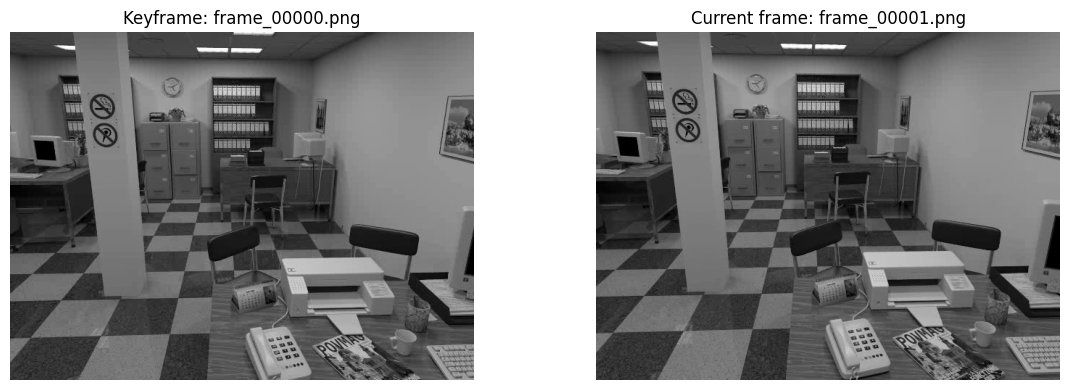

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [21]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 481.2
  pose_solver.camera.fy[0] = 480.0
  pose_solver.camera.cx[0] = 319.5
  pose_solver.camera.cy[0] = 239.5

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 481.2, 'fy': 480.0, 'cx': 319.5, 'cy': 239.5}

Initial photometric errors before optimization:
  level 4 = 1007.1387832699616
  level 3 = 1041.9444813094444
  level 2 = 1022.2308724832209


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [22]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  1007.1387832699616
 error improvement too small, level converged! it:  4  error:  585.1014530129994  lambda:  0.2
lvl:  3  initial error:  448.2220693776136
 error improvement too small, level converged! it:  4  error:  324.033469627339  lambda:  102.4
lvl:  2  initial error:  200.48167851828276
 error improvement too small, level converged! it:  3  error:  181.15468151584903  lambda:  0.4
Final photometric errors after optimization:
  level 4 = 581.0235512498151
  level 3 = 348.029187457652
  level 2 = 181.15468151584903


### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [23]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=1007.138783, final=581.023551, improvement=426.115232
  level 3: initial=1041.944481, final=348.029187, improvement=693.915294
  level 2: initial=1022.230872, final=181.154682, improvement=841.076191

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [24]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999935  0.001714 -0.011253  0.022111]
 [-0.00189   0.999877 -0.015591  0.020602]
 [ 0.011225  0.015612  0.999815  0.032443]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [25]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[-0.    0.   -0.01  0.04]
 [-0.   -0.   -0.01  0.04]
 [ 0.01  0.01 -0.    0.03]
 [ 0.    0.    0.    0.  ]]


----------- 

## Evaluation

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [26]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


In [27]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [28]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 79315344.0


In [33]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 297907
  difference > 200         = 3
  150 <= difference <= 200 = 115
  100 <= difference < 150  = 878
   50 <= difference < 100  = 7086
   30 <= difference < 50   = 10773
   10 <= difference < 30   = 36850
    0 <= difference < 10   = 242202


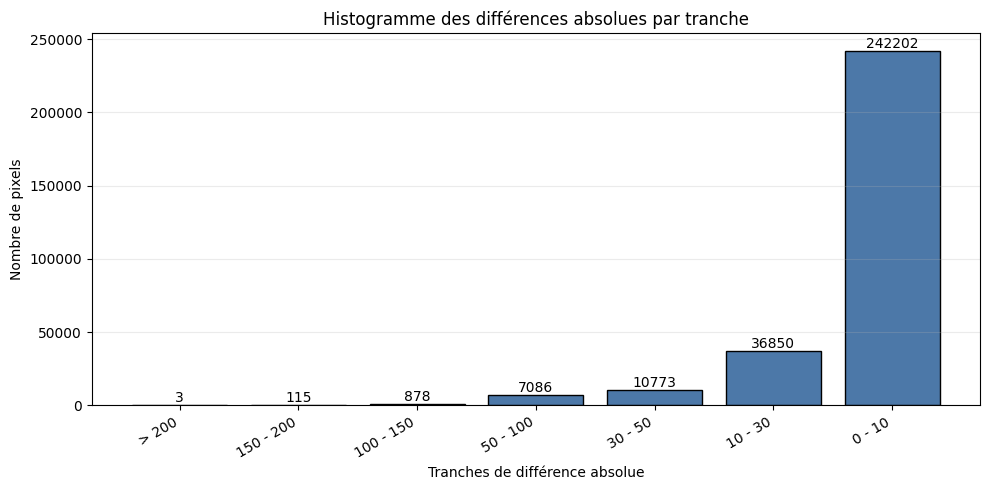

In [36]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


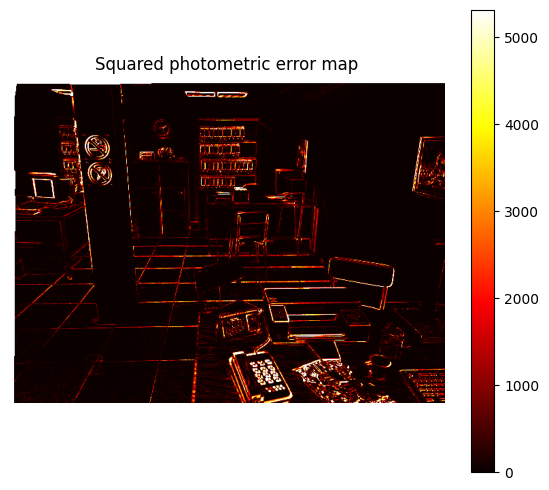

In [30]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [31]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
## Scale sur toutes les images

In [39]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
frame_paths = real_frame_paths[:10]  # Remplace par fake_frame_paths[:5] si tu veux traiter la sequence fake.

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_keyframe = None
sequence_results = []

print(f"Processing {len(frame_paths)} frame(s) ...")

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)
    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        keyframe_image_path = image_path
        print(f"[frame {step:04d}] keyframe initialized: {image_path.name}")
        print(f"  depth valid ratio = {float(depth_valid_mask.mean()):.4f}")
        continue

    pose_solver.optPose(current_frame, sequence_keyframe)
    pose_matrix = current_frame.pose.as_matrix()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": pose_matrix,
    })

    print(f"[frame {step:04d}] {image_path.name}")
    print()
    print(f"  depth valid ratio = {float(depth_valid_mask.mean()):.4f}")
    print()
    print(pose_matrix)
    print("--------------------------------------------------------------")
    print()
    print()
    print()
    print()

print()
print(f"Done. Processed {len(sequence_results)} estimated pose(s) after the keyframe.")

Processing 10 frame(s) ...
[frame 0000] keyframe initialized: frame_00000.png
  depth valid ratio = 1.0000
lvl:  4  initial error:  1007.1387832699616
 error improvement too small, level converged! it:  5  error:  584.4027452183351  lambda:  879609302220.8
lvl:  3  initial error:  449.38787031855657
 error improvement too small, level converged! it:  4  error:  324.82771364754547  lambda:  51.2
lvl:  2  initial error:  200.64683945842506
 error improvement too small, level converged! it:  3  error:  181.14478903555863  lambda:  0.4
[frame 0001] frame_00001.png

  depth valid ratio = 1.0000

[[ 0.999935  0.001713 -0.011252  0.022102]
 [-0.001889  0.999877 -0.015594  0.020617]
 [ 0.011223  0.015614  0.999815  0.032437]
 [ 0.        0.        0.        1.      ]]
--------------------------------------------------------------




lvl:  4  initial error:  1535.7956273764255
 error improvement too small, level converged! it:  7  error:  533.5080306263827  lambda:  439804651110.4
lvl:  3  ini

KeyboardInterrupt: 